In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import xarray as xr
from netCDF4 import Dataset
import seaborn as sns
import pandas as pd
import pickle
import cartopy.crs as ccrs
import cartopy.feature as cf
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator)
import matplotlib.cm as cm
import function_trends_copy as f

In [2]:
basins = {
    "North Atlantic": (0, 70, -90, 10, 'NA'),
    "South Atlantic": (-70, -5, -60, 20, 'SA'),
    "Indian Ocean": (-70, 20, 30, 110, 'IO'),
    "North Pacific": (5, 65, -100, 140, 'NP'),
    "South Pacific": (-70, -5, -80, 160, 'SP'),
    "Southern Ocean": (-70, -20, -180, 179, 'SO')
}

binstep = 3
startyear = 1836
endyear = 1901
periods = [startyear,1848,1860,1890,endyear]

In [3]:
# Open logbook data
datana = f.open_logbook('/home/neele.sander/Downloads/tier4_2025-08-16.csv', -180, 179, -90, 90)
# Rename columns
# datana = datana.rename(columns={"Wind Speed/Force" :"Wind description","Wind Force": "Wind Speed/Force"})
#whaler data between start and endyear
datana = datana[(datana['year'] >= startyear) & (datana['year'] < endyear)]

#20CR speed
dsu = xr.open_dataset('/data0/neele.sander/uwnd.10m.mon.mean.nc')
dsv = xr.open_dataset('/data0/neele.sander/vwnd.10m.mon.mean.nc')
#need to open the whole thing and then process individual basins
data_model_raw = f.open_model(dsu, dsv, -90, 90 ,-180, 179)
data_model_raw['speed'] = data_model_raw['speed'].where(data_model_raw['angle'] > 180,data_model_raw['speed']*(-1))

In [4]:
# Process each basin 20CR
results = {}
data_20CR = {}
for basin_name, bounds in basins.items():
    latmin, latmax, lonmin, lonmax, basin_code = bounds
    
    if "Pacific" in basin_name:
        data_model_part1 = data_model_raw.sel(lat=slice(latmin, latmax), lon=slice(lonmax, 179))
        data_model_part2 = data_model_raw.sel(lat=slice(latmin, latmax), lon=slice(-180, lonmin))
        data_model = xr.combine_by_coords([data_model_part1, data_model_part2])
    elif "North Atlantic" in basin_name: #no winter for North Atlantic
        data_model_season = data_model_raw.groupby('time.season')
        data_model_noDJF = xr.concat([data_model_season['MAM'], data_model_season['JJA'], data_model_season['SON']], dim='time').sortby('time')
        data_model = data_model_noDJF.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
    else:
        data_model = data_model_raw.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
    
    results[basin_name] = f.process_basin(data_model, binstep, startyear, endyear+90)#need more times for later
    data_20CR[basin_name] = data_model
    
# Access results
north_atlantic_20CR = results["North Atlantic"]
south_atlantic_20CR = results["South Atlantic"]
indian_ocean_20CR = results["Indian Ocean"]
north_pacific_20CR = results["North Pacific"]
south_pacific_20CR = results["South Pacific"]
southern_ocean_20CR = results["Southern Ocean"]

In [5]:
# Process whaler data for each basin
results_w = {}

for basin_name, bounds in basins.items():
    latmin, latmax, lonmin, lonmax, basin_code = bounds
    
    # Filter the whaler data based on basin bounds
    if "Pacific" in basin_name:
        data_whaler = datana[((datana['Longitudegrid'] >= lonmax) | 
                             ((datana['Longitudegrid'] >= -180) & (datana['Longitudegrid'] <= lonmin))) & 
                            (datana['Latitudegrid'].between(latmin, latmax))]
    elif "North Atlantic" in basin_name:
        data_whaler = datana[(datana['Longitudegrid'].between(lonmin, lonmax)) & 
                             (datana['Latitudegrid'].between(latmin, latmax))]
        data_whaler = data_whaler.mask((data_whaler['Longitudegrid'] < -70) & (data_whaler['Latitudegrid'] < 10))
    else:
        data_whaler = datana[(datana['Longitudegrid'].between(lonmin, lonmax)) & 
                             (datana['Latitudegrid'].between(latmin, latmax))]

    # Define latitude bins based on the basin latitude bounds
    bins = np.arange(latmin, latmax, binstep)

    # Process whaler data for the given basin using the arbitrary time periods
    results_w[basin_name] = f.process_whaler(data_whaler, periods, bins, basin_name)

# Access results
data_whaler_NA = results_w.get("North Atlantic", None)
data_whaler_SA = results_w.get("South Atlantic", None)
data_whaler_IO = results_w.get("Indian Ocean", None)
data_whaler_NP = results_w.get("North Pacific", None)
data_whaler_SP = results_w.get("South Pacific", None)
data_whaler_SO = results_w.get("Southern Ocean", None)


/home/neele.sander/Downloads/paper_2025/function_trends_copy.py:256: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_whaler['season'] = data_whaler['month'].apply(month_to_season)
/home/neele.sander/Downloads/paper_2025/function_trends_copy.py:256: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_whaler['season'] = data_whaler['month'].apply(month_to_season)
/home/neele.sander/Downloads/paper_2025/function_trends_copy.py:256: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

/tmp/ipykernel_3883445/2219499968.py:20: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(left = 0.13)
/tmp/ipykernel_3883445/2219499968.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')


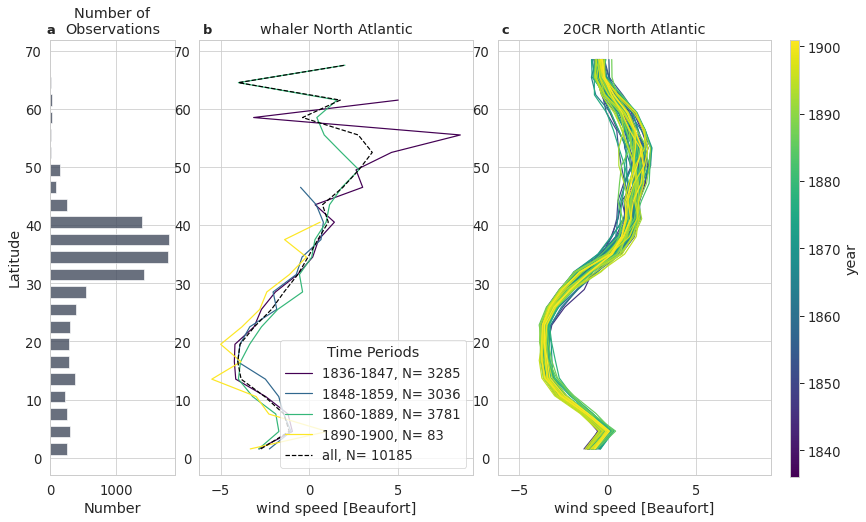

In [6]:
basin_name = "North Atlantic"  # Specify the basin you want to plot
sns.set(style='whitegrid', context='paper',font_scale = 1.5)
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
gs = GridSpec(4, 5, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:1])
ax1 = fig.add_subplot(gs[:, 1:3], sharey = ax0)
ax2 = fig.add_subplot(gs[:, 3:5], sharex=ax1, sharey = ax0)

f.plot_amount_per_bin(results_w, basin_name, ax0)
f.plot_whaler_data(results_w, basin_name, periods, ax1)
f.plot_20CR_data(results, basin_name, ax2, startyear, endyear)
ax0.text(-50,73, 'a', weight = 'bold', size = 13)
ax1.text(-6,73, 'b', weight = 'bold', size = 13)
ax2.text(-6,73, 'c', weight = 'bold', size = 13)
#ax1.set_yticklabels([])

norm = plt.Normalize(startyear, endyear)
sm = plt.cm.ScalarMappable(cmap= 'viridis', norm=norm)
fig.subplots_adjust(left = 0.13)
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.76])
c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')
c.set_label('year')
plt.savefig('plots/paper/NAtrend.png', dpi = 300)
plt.show()

In [7]:
results['North Atlantic']

,lat_bins,year,speed,Latitude_bin
0,"(-0.07, 3.043]",1836,-1.102728,1.4865
1,"(-0.07, 3.043]",1837,-1.086086,1.4865
2,"(-0.07, 3.043]",1838,-1.015891,1.4865
3,"(-0.07, 3.043]",1839,-1.132758,1.4865
4,"(-0.07, 3.043]",1840,-1.145896,1.4865
...,...,...,...,...
4111,"(66.957, 70.0]",1987,-0.551876,68.4785
4112,"(66.957, 70.0]",1988,-0.299620,68.4785
4113,"(66.957, 70.0]",1989,-0.017806,68.4785
4114,"(66.957, 70.0]",1990,-0.105651,68.4785


/tmp/ipykernel_3883445/4256881623.py:20: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(left = 0.13)
/tmp/ipykernel_3883445/4256881623.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')


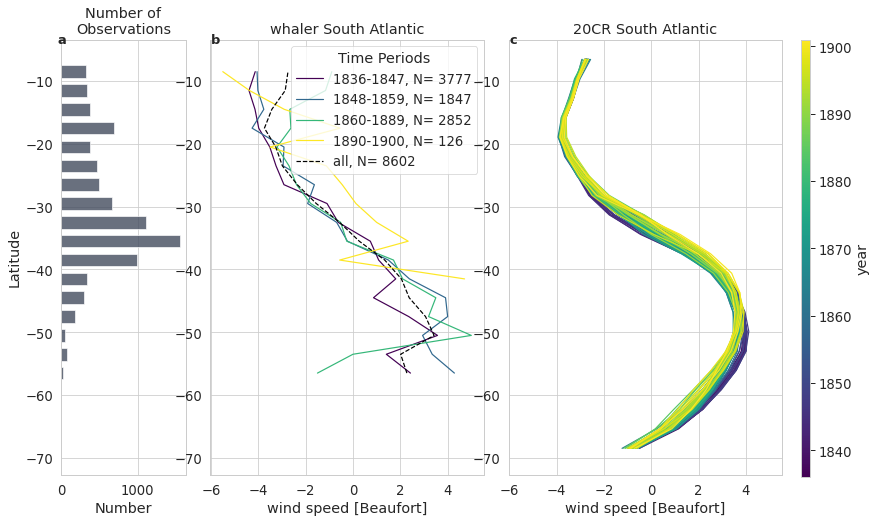

In [8]:
basin_name = "South Atlantic"  # Specify the basin you want to plot
sns.set(style='whitegrid', context='paper',font_scale = 1.5)
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
gs = GridSpec(4, 5, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:1])
ax1 = fig.add_subplot(gs[:, 1:3], sharey = ax0)
ax2 = fig.add_subplot(gs[:, 3:5], sharex=ax1, sharey = ax0)

f.plot_amount_per_bin(results_w, basin_name, ax0)
f.plot_whaler_data(results_w, basin_name, periods, ax1)
f.plot_20CR_data(results, basin_name, ax2, startyear, endyear)

ax0.text(-55,-4, 'a', weight = 'bold', size = 13)
ax1.text(-6,-4, 'b', weight = 'bold', size = 13)
ax2.text(-6,-4, 'c', weight = 'bold', size = 13)

norm = plt.Normalize(startyear, endyear)
sm = plt.cm.ScalarMappable(cmap= 'viridis', norm=norm)
fig.subplots_adjust(left = 0.13)
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.76])
c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')
c.set_label('year')
plt.savefig('plots/paper/SAtrend.png', dpi = 300)
plt.show()

/tmp/ipykernel_3883445/460068446.py:20: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(left = 0.13)
/tmp/ipykernel_3883445/460068446.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')


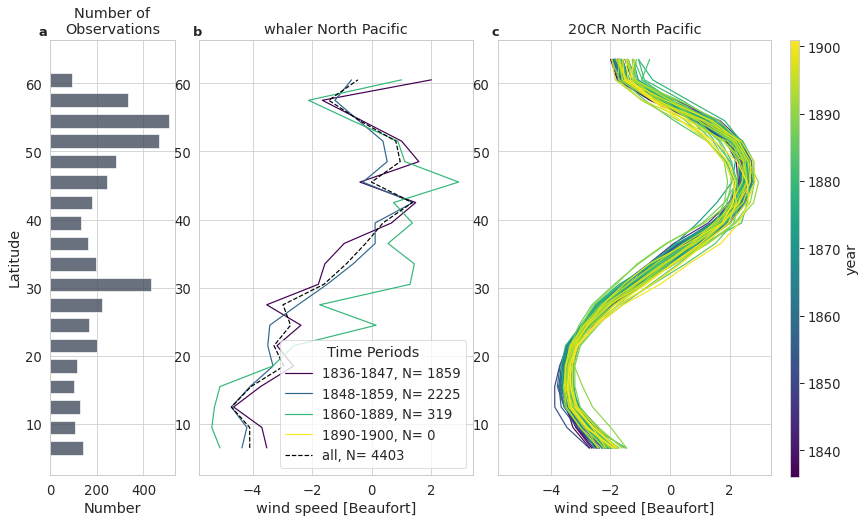

In [9]:
basin_name = "North Pacific"  # Specify the basin you want to plot
sns.set(style='whitegrid', context='paper',font_scale = 1.5)
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
gs = GridSpec(4, 5, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:1])
ax1 = fig.add_subplot(gs[:, 1:3], sharey = ax0)
ax2 = fig.add_subplot(gs[:, 3:5], sharex=ax1, sharey = ax0)

f.plot_amount_per_bin(results_w, basin_name, ax0)
f.plot_whaler_data(results_w, basin_name, periods, ax1)
f.plot_20CR_data(results, basin_name, ax2, startyear, endyear)

ax0.text(-50,67, 'a', weight = 'bold', size = 13)
ax1.text(-6,67, 'b', weight = 'bold', size = 13)
ax2.text(-6,67, 'c', weight = 'bold', size = 13)

norm = plt.Normalize(startyear, endyear)
sm = plt.cm.ScalarMappable(cmap= 'viridis', norm=norm)
fig.subplots_adjust(left = 0.13)
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.76])
c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')
c.set_label('year')
plt.savefig('plots/paper/NPtrend.png', dpi = 300)
plt.show()

/tmp/ipykernel_3883445/629420565.py:20: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(left = 0.13)
/tmp/ipykernel_3883445/629420565.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')


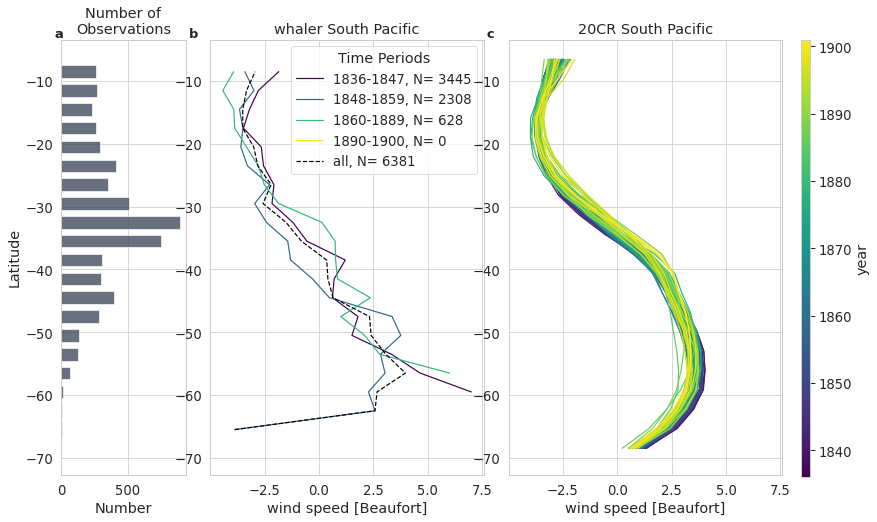

In [10]:
basin_name = "South Pacific"  # Specify the basin you want to plot
sns.set(style='whitegrid', context='paper',font_scale = 1.5)
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
gs = GridSpec(4, 5, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:1])
ax1 = fig.add_subplot(gs[:, 1:3], sharey = ax0)
ax2 = fig.add_subplot(gs[:, 3:5], sharex=ax1, sharey = ax0)

f.plot_amount_per_bin(results_w, basin_name, ax0)
f.plot_whaler_data(results_w, basin_name, periods, ax1)
f.plot_20CR_data(results, basin_name, ax2, startyear, endyear)

ax0.text(-50,-3, 'a', weight = 'bold', size = 13)
ax1.text(-6,-3, 'b', weight = 'bold', size = 13)
ax2.text(-6,-3, 'c', weight = 'bold', size = 13)

norm = plt.Normalize(startyear, endyear)
sm = plt.cm.ScalarMappable(cmap= 'viridis', norm=norm)
fig.subplots_adjust(left = 0.13)
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.76])
c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')
c.set_label('year')
plt.savefig('plots/paper/SPtrend.png', dpi = 300)
plt.show()

/tmp/ipykernel_3883445/3662110359.py:20: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(left = 0.13)
/tmp/ipykernel_3883445/3662110359.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')


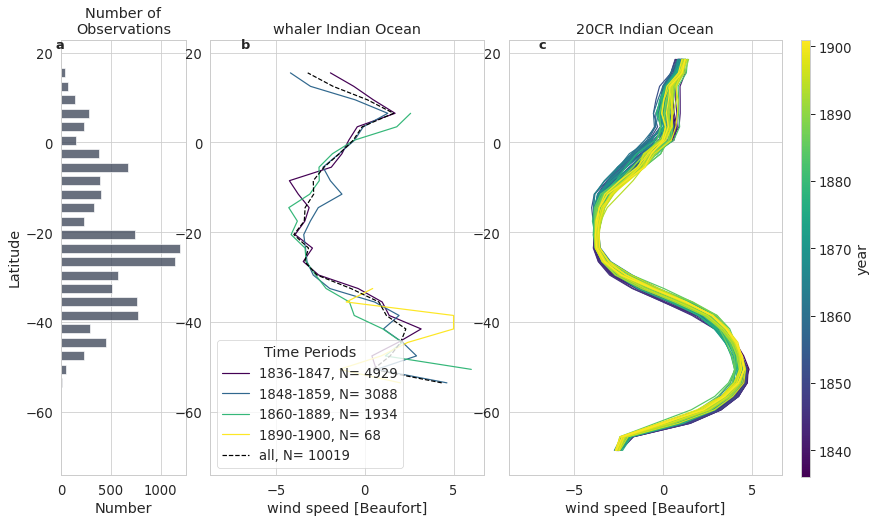

In [11]:
basin_name = "Indian Ocean"  # Specify the basin you want to plot
sns.set(style='whitegrid', context='paper',font_scale = 1.5)
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
gs = GridSpec(4, 5, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:1])
ax1 = fig.add_subplot(gs[:, 1:3], sharey = ax0)
ax2 = fig.add_subplot(gs[:, 3:5], sharex=ax1, sharey = ax0)

f.plot_amount_per_bin(results_w, basin_name, ax0)
f.plot_whaler_data(results_w, basin_name, periods, ax1)
f.plot_20CR_data(results, basin_name, ax2, startyear, endyear)

ax0.text(-60,21, 'a', weight = 'bold', size = 13)
ax1.text(-7,21, 'b', weight = 'bold', size = 13)
ax2.text(-7,21, 'c', weight = 'bold', size = 13)

norm = plt.Normalize(startyear, endyear)
sm = plt.cm.ScalarMappable(cmap= 'viridis', norm=norm)
fig.subplots_adjust(left = 0.13)
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.76])
c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')
c.set_label('year')
plt.savefig('plots/paper/IOtrend.png', dpi = 300)
plt.show()

/tmp/ipykernel_3883445/1106172485.py:20: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  fig.subplots_adjust(left = 0.13)
/tmp/ipykernel_3883445/1106172485.py:22: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')


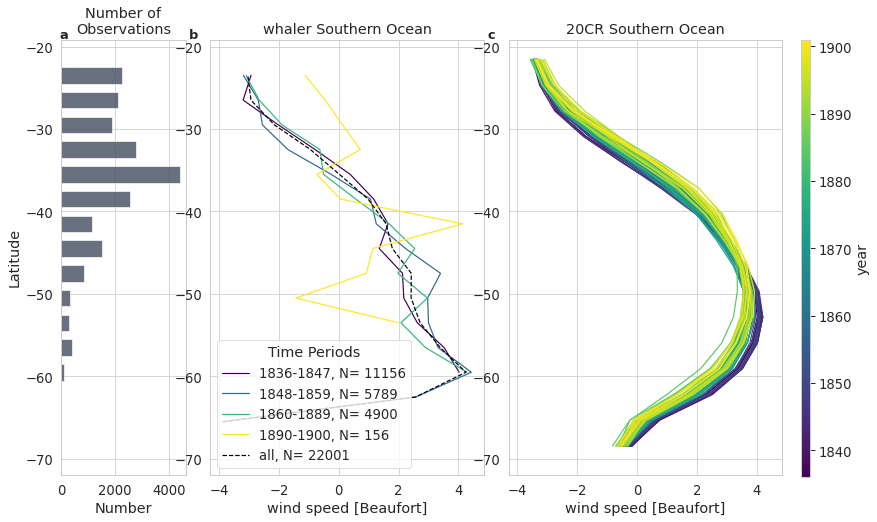

In [12]:
basin_name = "Southern Ocean"  # Specify the basin you want to plot
sns.set(style='whitegrid', context='paper',font_scale = 1.5)
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
gs = GridSpec(4, 5, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:1])
ax1 = fig.add_subplot(gs[:, 1:3], sharey = ax0)
ax2 = fig.add_subplot(gs[:, 3:5], sharex=ax1, sharey = ax0)

f.plot_amount_per_bin(results_w, basin_name, ax0)
f.plot_whaler_data(results_w, basin_name, periods, ax1)
f.plot_20CR_data(results, basin_name, ax2, startyear, endyear)

ax0.text(-60,-19, 'a', weight = 'bold', size = 13)
ax1.text(-5,-19, 'b', weight = 'bold', size = 13)
ax2.text(-5,-19, 'c', weight = 'bold', size = 13)

norm = plt.Normalize(startyear, endyear)
sm = plt.cm.ScalarMappable(cmap= 'viridis', norm=norm)
fig.subplots_adjust(left = 0.13)
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.76])
c = fig.colorbar(sm, cax = cbar_ax, orientation='vertical')
c.set_label('year')
plt.savefig('plots/paper/SOtrend.png', dpi = 300)
plt.show()

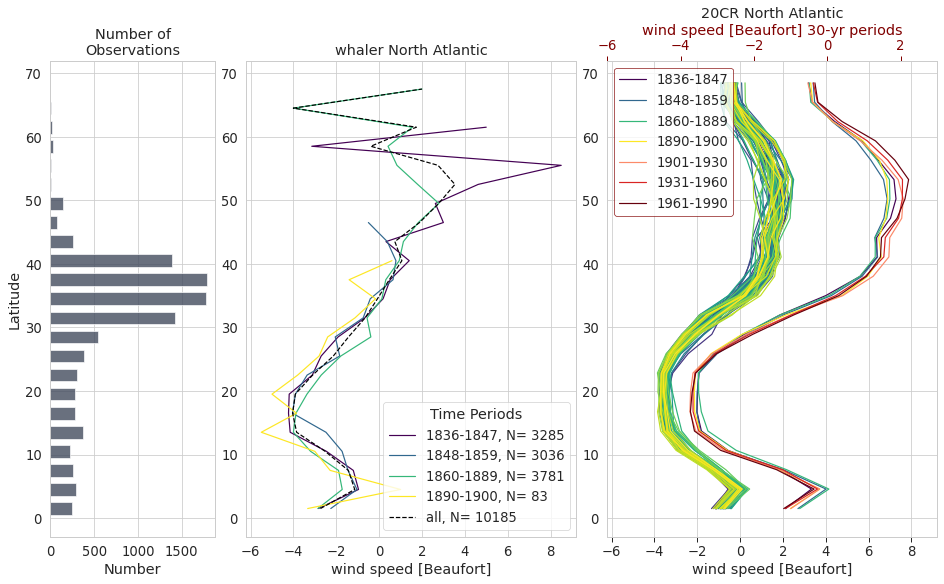

In [13]:
# North Atlantic other version
periods = [startyear,1848,1860,1890,endyear]
periods_ex = periods + [endyear+30, endyear+60, endyear+90]
basin_name = 'North Atlantic'
sns.set(style='whitegrid', context='paper',font_scale = 1.5)
fig = plt.figure(figsize=(13, 8), constrained_layout=True)
gs = GridSpec(4, 5, figure=fig)

ax0 = fig.add_subplot(gs[:, 0:1])
ax1 = fig.add_subplot(gs[:, 1:3], sharey = ax0)
ax2 = fig.add_subplot(gs[:, 3:5], sharex=ax1, sharey = ax0)

f.plot_amount_per_bin(results_w, basin_name, ax0)
f.plot_whaler_data(results_w, basin_name, periods, ax1)
f.plot_20CR_data(results, basin_name, ax2, startyear, endyear)
#add trends
ax3 = ax2.twiny()
f.plot_20CR_data_trend(results, basin_name, ax3, periods_ex, basins, binstep)
plt.savefig('plots/paper/NAtrend_final.png', dpi = 300)